# 17 — Partial order of groups from positive rules

Long-format `(period, group, resource_meta, has_right)` table from positive (`MORE`) rules in `data/rules_dataset_april_2026.tsv`, plus a Hasse diagram of groups ordered by right-set inclusion, one panel per period.

* **Filter** — `directionality == 'MORE'` only.
* **Periods (3)** — `Classical`, `Late Classical`, `Roman` (= `Hellenistic & Early Roman` + `High Roman Empire`).
* **Group axis** — `group` (fine-grained, not `group_meta`).
* **Resource axis** — `resource_meta`.
* **Partial order** — `g₁ ≤ g₂` iff `rights(g₁) ⊆ rights(g₂)`. Hasse = transitive reduction.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)':                 'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Roman (165 BCE – 205 CE)',
]

MIN_RIGHTS = 3

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')
df_raw.shape, df_raw['directionality'].value_counts().to_dict()

((1011, 34), {'MORE': 549, 'LESS': 462})

In [3]:
positive = (df_raw[df_raw['directionality'] == 'MORE']
              .dropna(subset=['period', 'group', 'resource_meta'])
              .assign(period=lambda d: d['period'].map(PERIOD_MAP))
              .dropna(subset=['period'])
              [['period', 'group', 'resource_meta']])
positive.shape

(505, 3)

In [4]:
positive['period'].value_counts().reindex(PERIOD_ORDER)

period
Classical (500–360 BCE)         170
Late Classical (354–165 BCE)    205
Roman (165 BCE – 205 CE)        130
Name: count, dtype: int64

## Long-format 0/1 table

In [5]:
groups         = sorted(positive['group'].unique())
resource_metas = sorted(positive['resource_meta'].unique())
len(groups), len(resource_metas)

(175, 43)

In [6]:
attested = set(map(tuple, positive[['period', 'group', 'resource_meta']].drop_duplicates().values))

rights_long = pd.DataFrame(
    [(p, g, r, int((p, g, r) in attested))
     for p in PERIOD_ORDER
     for g in groups
     for r in resource_metas],
    columns=['period', 'group', 'resource_meta', 'has_right'],
)
rights_long.shape

(22575, 4)

In [7]:
rights_long.head()

,period,group,resource_meta,has_right
0,Classical (500–360 BCE),Actors and musicians,Access to education,0
1,Classical (500–360 BCE),Actors and musicians,Access to public honors,0
2,Classical (500–360 BCE),Actors and musicians,Access to religious rites,0
3,Classical (500–360 BCE),Actors and musicians,Access to the gymnasium,0
4,Classical (500–360 BCE),Actors and musicians,Eligibility for public office,0


In [8]:
rights_long.groupby('period')['has_right'].agg(['sum', 'count']).reindex(PERIOD_ORDER)

,sum,count
period,,
Classical (500–360 BCE),111,7525
Late Classical (354–165 BCE),134,7525
Roman (165 BCE – 205 CE),112,7525


## Hasse diagram — groups ordered by right-set inclusion

For each period, each group is the set of `resource_meta` it holds. `g₁ ≤ g₂` iff `rights(g₁) ⊆ rights(g₂)`. The Hasse diagram is the transitive reduction. Groups with identical right-sets collapse into one node. Groups with fewer than `MIN_RIGHTS` rights are dropped to keep the figure legible.

In [9]:
def right_sets(period: str) -> dict[str, frozenset]:
    sub = rights_long[(rights_long['period'] == period) & (rights_long['has_right'] == 1)]
    sets = {g: frozenset(grp['resource_meta']) for g, grp in sub.groupby('group')}
    return {g: s for g, s in sets.items() if len(s) >= MIN_RIGHTS}

{p: len(right_sets(p)) for p in PERIOD_ORDER}

{'Classical (500–360 BCE)': 6,
 'Late Classical (354–165 BCE)': 10,
 'Roman (165 BCE – 205 CE)': 9}

In [10]:
def hasse_graph(sets: dict[str, frozenset]) -> tuple[nx.DiGraph, dict[frozenset, list[str]]]:
    classes: dict[frozenset, list[str]] = {}
    for g, s in sets.items():
        classes.setdefault(s, []).append(g)
    nodes = list(classes.keys())

    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        if a < b:
            G.add_edge(a, b)
        elif b < a:
            G.add_edge(b, a)
    return nx.transitive_reduction(G), classes

In [11]:
def layered_positions(G: nx.DiGraph) -> dict:
    # y = number of rights; x evenly spread within each level
    levels: dict[int, list] = {}
    for n in G.nodes:
        levels.setdefault(len(n), []).append(n)
    pos = {}
    for y, nodes in levels.items():
        nodes = sorted(nodes, key=lambda s: sorted(s))
        for i, n in enumerate(nodes):
            x = (i + 1) / (len(nodes) + 1)
            pos[n] = (x, y)
    return pos

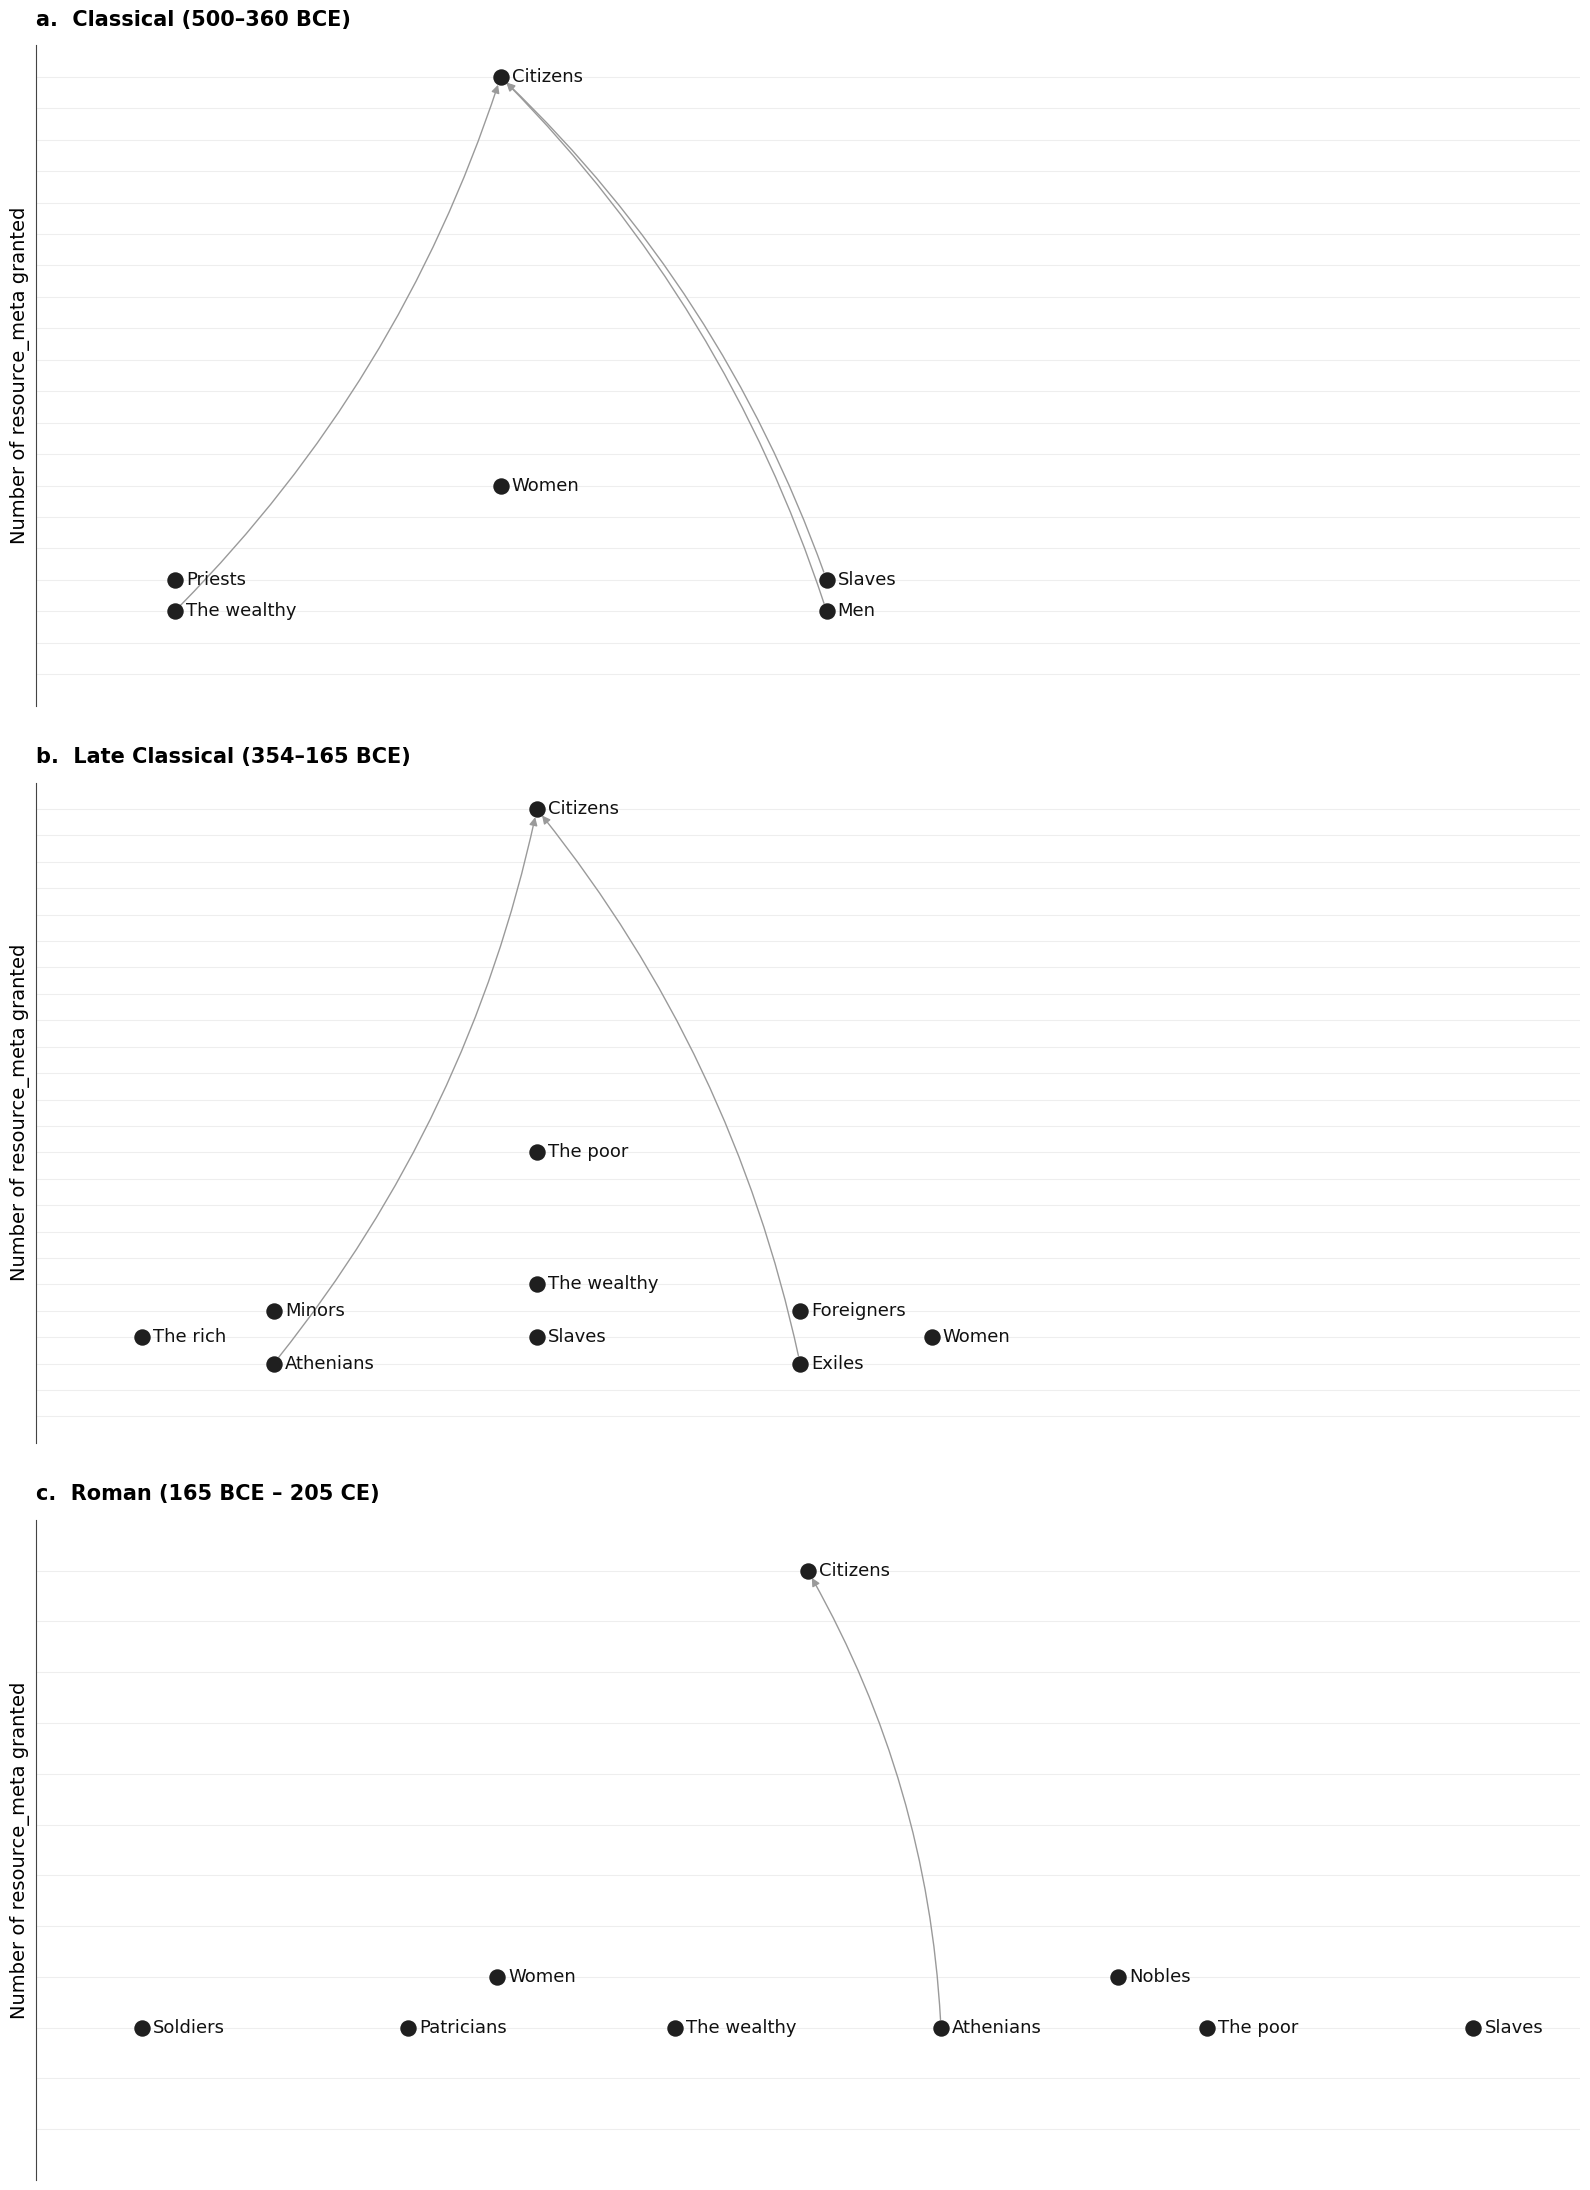

In [12]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  14,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
})

NODE_SIZE = 140

fig, axes = plt.subplots(3, 1, figsize=(16, 22))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sets = right_sets(period)
    G, classes = hasse_graph(sets)
    pos = layered_positions(G)

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=NODE_SIZE,
        node_color='#1f1f1f',
        linewidths=0,
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#9a9a9a',
        width=1.0,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12,
        node_size=NODE_SIZE,
        connectionstyle='arc3,rad=0.12',
        min_source_margin=4,
        min_target_margin=4,
    )

    for n, (x, y) in pos.items():
        ax.annotate(
            ', '.join(classes[n]),
            xy=(x, y), xytext=(8, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=13, color='#111111',
        )

    ymax = max(len(n) for n in G.nodes)
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_ylabel('Number of resource_meta granted')
    ax.set_yticks(range(1, ymax + 1))
    ax.set_ylim(0, ymax + 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0)
    ax.margins(x=0.08)
    ax.grid(axis='y', color='#eeeeee', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color('#444444')

fig.tight_layout(h_pad=3)
plt.show()